<a href="https://colab.research.google.com/github/edwardsajaaa/AppAbsensi/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

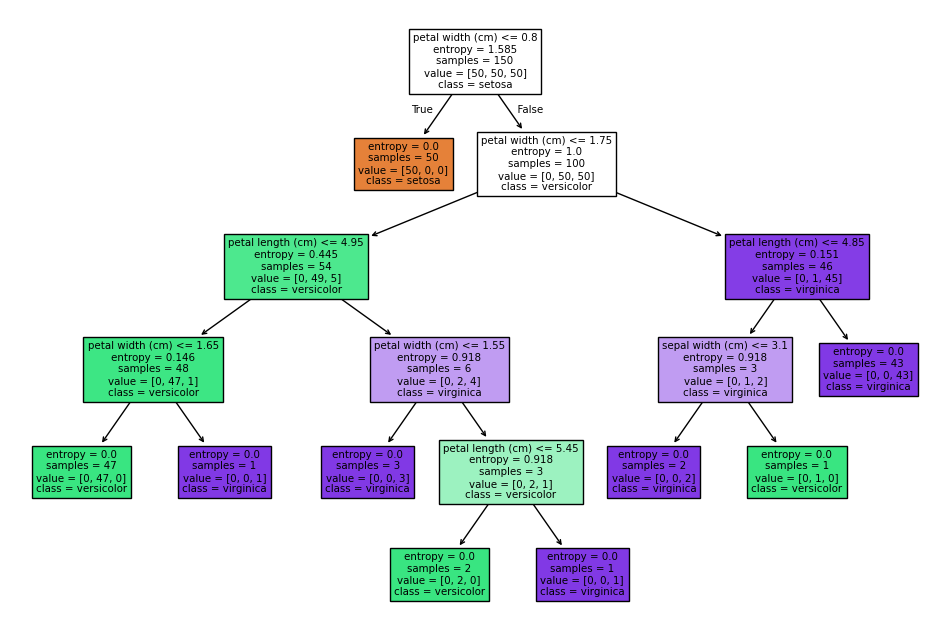

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

#load dataset
iris = load_iris()
X, y = iris.data, iris.target

#train model
clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit (X, y)

#visualize tree
plt.figure(figsize=(12,8))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=list(iris.target_names),
          filled=True)
plt.show()

=== Dataset ===
     Outlook Temperature Humidity   Windy PlayTennis
0      Sunny         Hot     High   Weak          No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No

=== Dataset Encoded ===


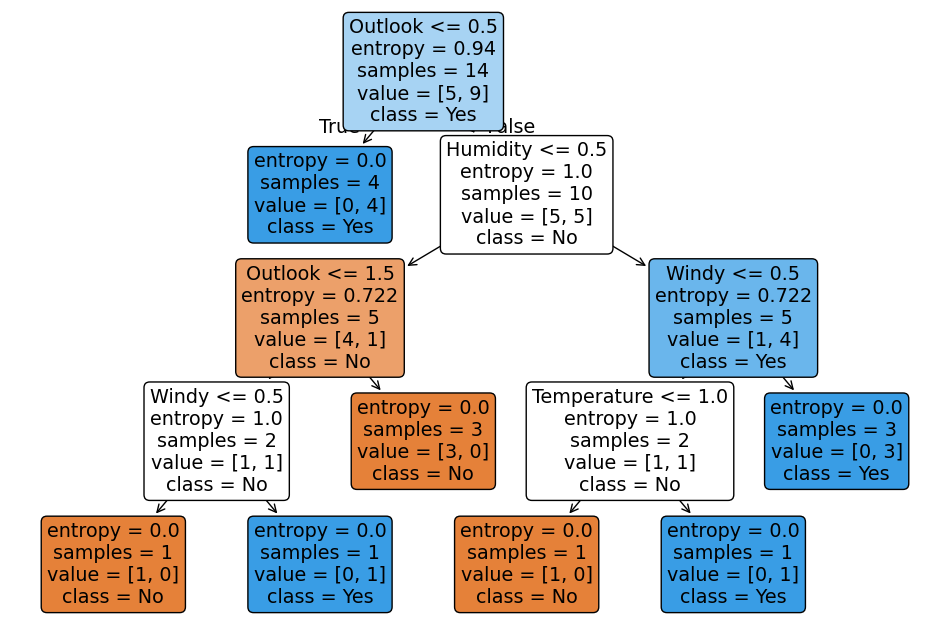

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': ['Weak ', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
              'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("=== Dataset ===")
print(df)

le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)
x = df_encoded.drop('PlayTennis', axis = 1)
y = df_encoded['PlayTennis']

print("\n=== Dataset Encoded ===")
clf = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
clf.fit(x, y)

plt.figure(figsize = (12, 8))
plot_tree(clf,
          filled = True,
          feature_names = list(x.columns),
          class_names = ['No', 'Yes'],
          rounded = True)
plt.show()

Akurasi (model pruned): 0.9666666666666667


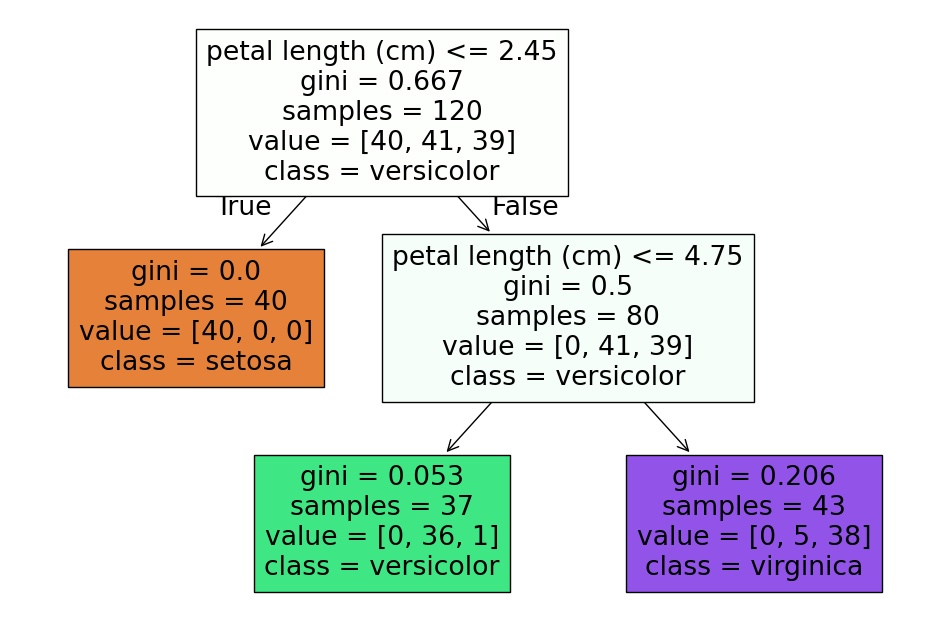

In [ ]:
# 1. Import Library
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree  # <- ini yang benar
from sklearn.model_selection import train_test_split         # <- pindah ke sini
import matplotlib.pyplot as plt

# 2. Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# 3. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Buat Model Decision Tree dengan pruning
clf_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    min_samples_split=4,
    random_state=42
)

# 5. Latih Model
clf_pruned.fit(X_train, y_train)

# 6. Evaluasi Akurasi
print("Akurasi (model pruned):", clf_pruned.score(X_test, y_test))

# 7. Visualisasi pohon hasil pruning
plt.figure(figsize=(12, 8))
plot_tree(
    clf_pruned,
    filled=True,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
plt.show()


Akurasi model: 1.0


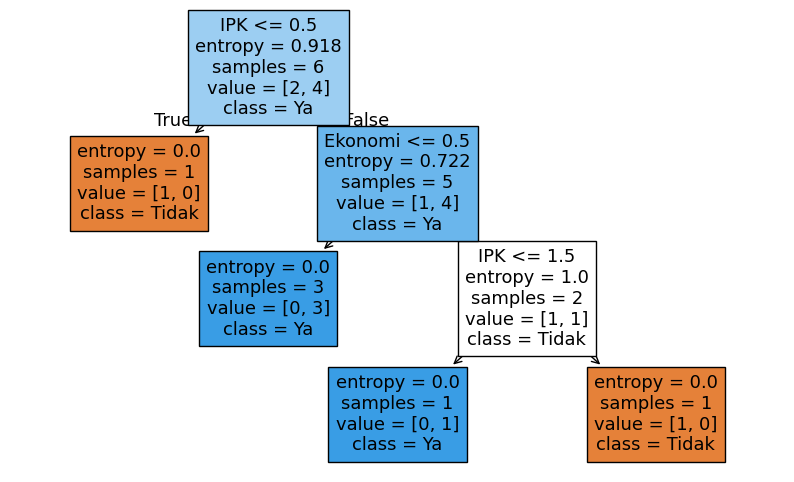

Prediksi penerimaan beasiswa: Tidak


In [ ]:
# 1. Import Library
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 2. Dataset sederhana
data = {
    'Nama': ['Rina', 'Joshua', 'Lina', 'Andi', 'Bella', 'Rey'],
    'IPK': ['Tinggi', 'Sedang', 'Tinggi', 'Rendah', 'Sedang', 'Tinggi'],
    'Ekonomi': ['Rendah', 'Rendah', 'Tinggi', 'Rendah', 'Tinggi', 'Rendah'],
    'Organisasi': ['Aktif', 'Tidak Aktif', 'Aktif', 'Tidak Aktif', 'Aktif', 'Aktif'],
    'Diterima_Beasiswa': ['Ya', 'Ya', 'Tidak', 'Tidak', 'Ya', 'Ya']
}

# 3. Ubah ke DataFrame
df = pd.DataFrame(data)

# 4. Encode data kategorikal ke numerik
le = LabelEncoder()
for col in ['IPK', 'Ekonomi', 'Organisasi', 'Diterima_Beasiswa']:
    df[col] = le.fit_transform(df[col])

# 5. Pisahkan fitur dan label
X = df[['IPK', 'Ekonomi', 'Organisasi']]
y = df['Diterima_Beasiswa']

# 6. Buat model Decision Tree
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# 7. Evaluasi sederhana
print("Akurasi model:", clf.score(X, y))

# 8. Visualisasi pohon keputusan
plt.figure(figsize=(10, 6))
plot_tree(clf,
          feature_names=['IPK', 'Ekonomi', 'Organisasi'],
          class_names=['Tidak', 'Ya'],
          filled=True)
plt.show()

# 9. Contoh prediksi
contoh = pd.DataFrame({
    'IPK': ['Tinggi'],
    'Ekonomi': ['Rendah'],
    'Organisasi': ['Aktif']
})

# Encode contoh data
for col in ['IPK', 'Ekonomi', 'Organisasi']:
    contoh[col] = le.fit_transform(contoh[col])

# Prediksi hasil
prediksi = clf.predict(contoh)
hasil = 'Ya' if prediksi[0] == 1 else 'Tidak'
print("Prediksi penerimaan beasiswa:", hasil)


/tmp/ipython-input-3409642804.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipython-input-3409642804.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Akurasi Model Overfit: 0.7932960893854749


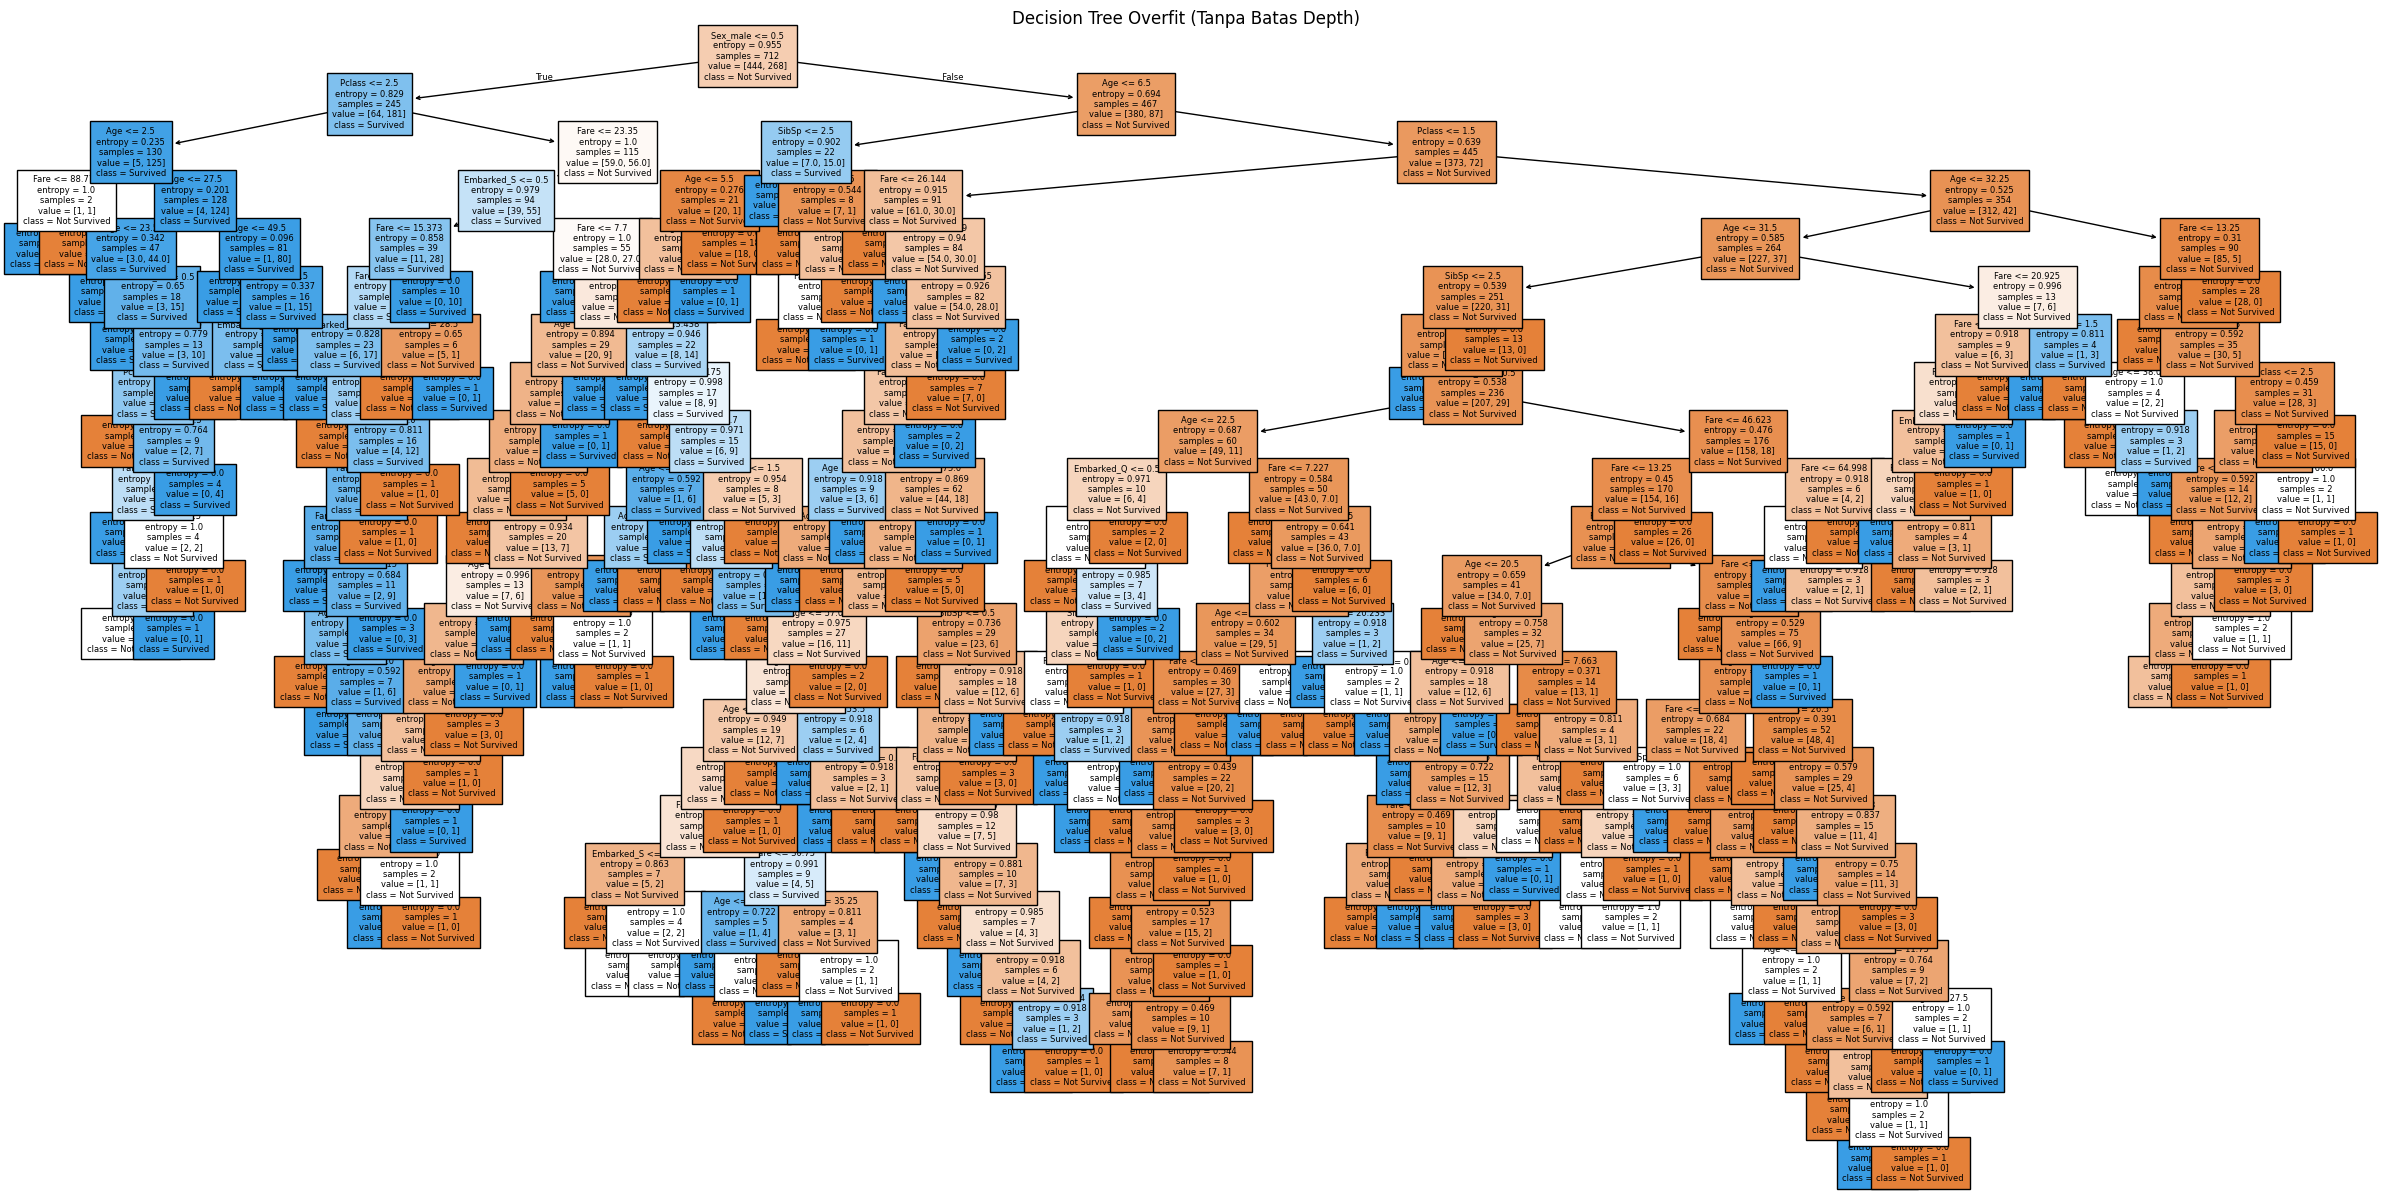

In [ ]:
# ===============================================================
# DECISION TREE - MODEL OVERFIT (TANPA BATAS DEPTH)
# ===============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ===============================================================
# 1. Load & Preprocessing
# ===============================================================
data = pd.read_csv("train.csv")

# Hapus kolom yang tidak relevan
data = data.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Tangani missing values
data["Age"].fillna(data["Age"].median(), inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

# One-hot encoding untuk kolom kategorikal
data = pd.get_dummies(data, columns=["Sex", "Embarked"], drop_first=True)

# Pisahkan fitur dan target
X = data.drop("Survived", axis=1)
y = data["Survived"]

# Split data (optional, biar bisa evaluasi juga)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================================================
# 2. Model Decision Tree Overfit
# ===============================================================
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,          # tanpa batas kedalaman
    min_samples_split=2,     # node sekecil apa pun akan di-split
    min_samples_leaf=1,      # tiap daun boleh hanya berisi 1 sample
    random_state=42
)

model.fit(X_train, y_train)

# Prediksi & evaluasi
y_pred = model.predict(X_val)
print("Akurasi Model Overfit:", accuracy_score(y_val, y_pred))

# ===============================================================
# 3. Visualisasi Pohon Keputusan
# ===============================================================
plt.figure(figsize=(30, 15))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    fontsize=6
)
plt.title("Decision Tree Overfit (Tanpa Batas Depth)")
plt.show()


Data Awal:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN   

/tmp/ipython-input-102986333.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipython-input-102986333.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 


Parameter terbaik: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

=== MODEL OPTIMAL ===
Akurasi Training: 0.8342696629213483
Akurasi Testing : 0.7988826815642458

Confusion Matrix (Testing):
 [[92 13]
 [23 51]]

Classification Report (Testing):
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



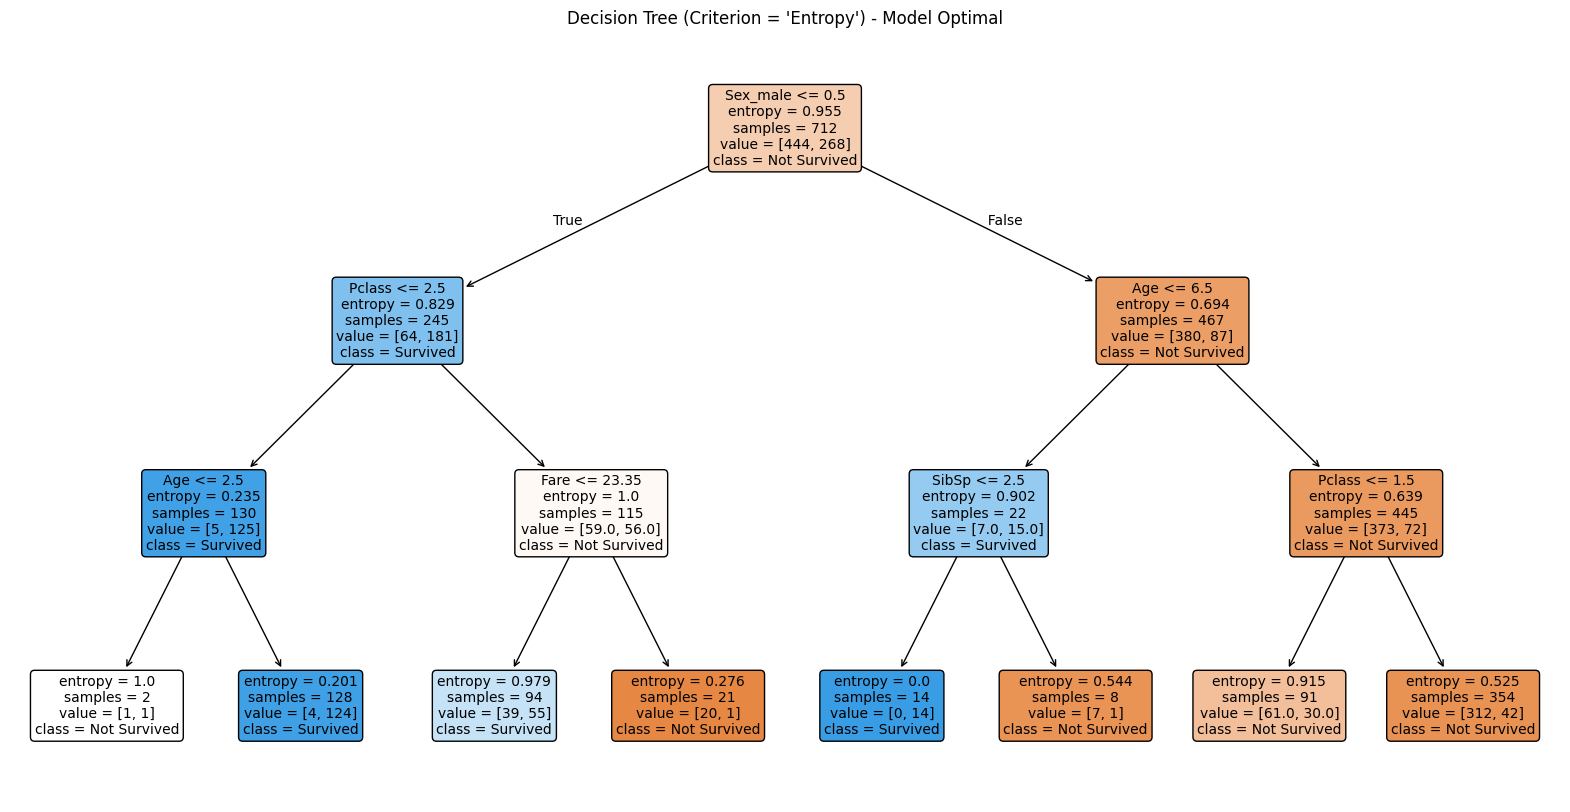


=== Perbandingan Akurasi ===
     Model  Akurasi Training  Akurasi Testing
0  Overfit          0.978933         0.793296
1  Optimal          0.834270         0.798883


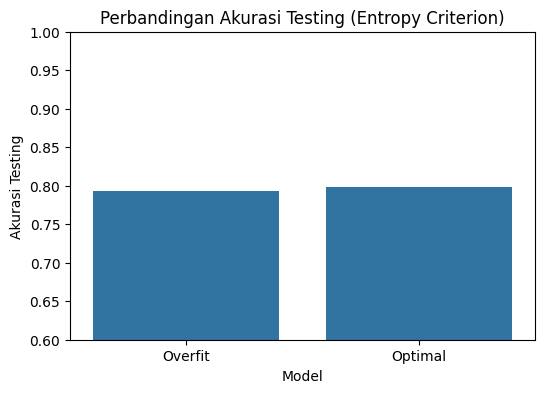

In [ ]:
# ======================================
# DECISION TREE (CRITERION = 'ENTROPY')
# Dataset: Titanic
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# =====================
# 1. LOAD DATASET
# =====================
data = pd.read_csv("train.csv")

# Menampilkan beberapa baris pertama
print("Data Awal:")
print(data.head())

# =====================
# 2. PREPROCESSING
# =====================

# Pilih fitur penting (bisa disesuaikan)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
data = data[features + ['Survived']]

# Tangani missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Ubah data kategorikal ke numerik
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

# Pisahkan fitur dan label
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split data training & testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nJumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

# =====================
# 3. MODEL OVERFIT (tanpa tuning)
# =====================

model_overfit = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

model_overfit.fit(X_train, y_train)

# Prediksi
y_pred_train_overfit = model_overfit.predict(X_train)
y_pred_test_overfit = model_overfit.predict(X_test)

# Evaluasi
acc_train_overfit = accuracy_score(y_train, y_pred_train_overfit)
acc_test_overfit = accuracy_score(y_test, y_pred_test_overfit)

print("\n=== MODEL OVERFIT ===")
print("Akurasi Training:", acc_train_overfit)
print("Akurasi Testing :", acc_test_overfit)
print("\nConfusion Matrix (Testing):\n", confusion_matrix(y_test, y_pred_test_overfit))

# =====================
# 4. MODEL OPTIMAL (dengan tuning)
# =====================

param_grid = {
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nParameter terbaik:", grid_search.best_params_)

# Evaluasi model optimal
y_pred_train_opt = best_model.predict(X_train)
y_pred_test_opt = best_model.predict(X_test)

acc_train_opt = accuracy_score(y_train, y_pred_train_opt)
acc_test_opt = accuracy_score(y_test, y_pred_test_opt)

print("\n=== MODEL OPTIMAL ===")
print("Akurasi Training:", acc_train_opt)
print("Akurasi Testing :", acc_test_opt)
print("\nConfusion Matrix (Testing):\n", confusion_matrix(y_test, y_pred_test_opt))
print("\nClassification Report (Testing):\n", classification_report(y_test, y_pred_test_opt))

# =====================
# 5. VISUALISASI POHON
# =====================

plt.figure(figsize=(20, 10))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (Criterion = 'Entropy') - Model Optimal")
plt.show()

# =====================
# 6. PERBANDINGAN PERFORMA
# =====================

compare = pd.DataFrame({
    'Model': ['Overfit', 'Optimal'],
    'Akurasi Training': [acc_train_overfit, acc_train_opt],
    'Akurasi Testing': [acc_test_overfit, acc_test_opt]
})

print("\n=== Perbandingan Akurasi ===")
print(compare)

plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Akurasi Testing', data=compare)
plt.title('Perbandingan Akurasi Testing (Entropy Criterion)')
plt.ylim(0.6, 1.0)
plt.show()


<>:25: SyntaxWarning: invalid escape sequence '\.'
<>:25: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-393011634.py:25: SyntaxWarning: invalid escape sequence '\.'
  df_processed['Title'] = df_processed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipython-input-393011634.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
/tmp/ipython-input-393011634.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.8175317640106371
Training Accuracy: 0.8961
Validation Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



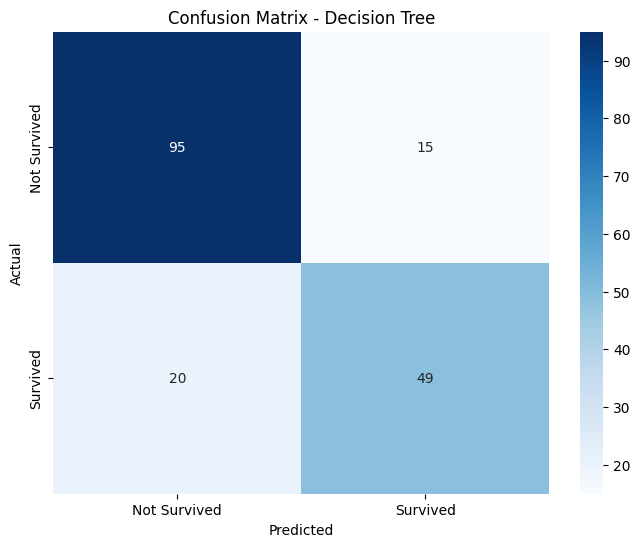

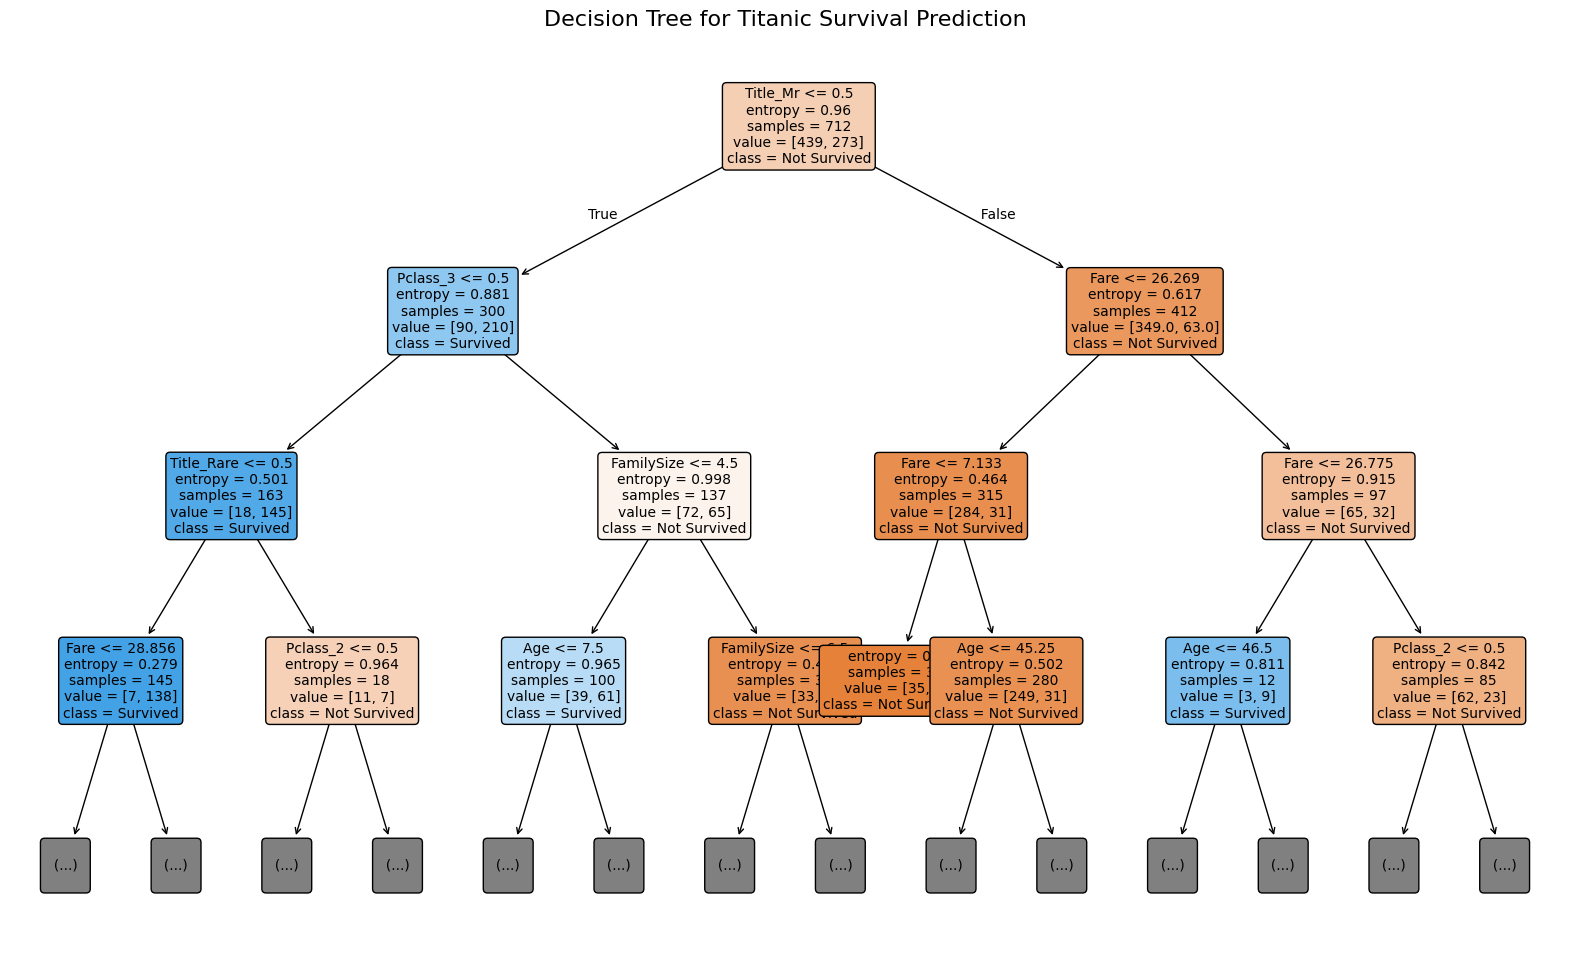

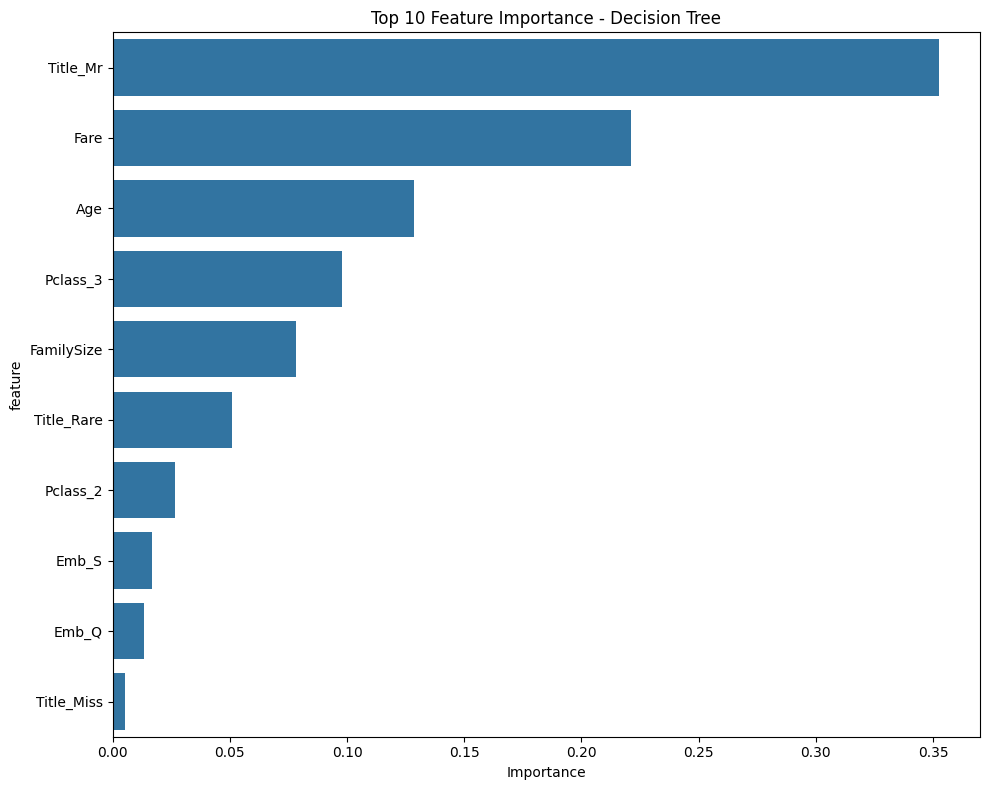

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Preprocessing function
def preprocess_data(df):
    df_processed = df.copy()

    # Handle missing values
    df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
    df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)
    df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)

    # Feature engineering
    df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
    df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
    df_processed['Title'] = df_processed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df_processed['Title'] = df_processed['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr',
                                                        'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df_processed['Title'] = df_processed['Title'].replace('Mlle', 'Miss')
    df_processed['Title'] = df_processed['Title'].replace('Ms', 'Miss')
    df_processed['Title'] = df_processed['Title'].replace('Mme', 'Mrs')

    # Convert categorical variables
    df_processed['Sex'] = df_processed['Sex'].map({'male': 0, 'female': 1})
    df_processed = pd.get_dummies(df_processed, columns=['Embarked', 'Title', 'Pclass'], prefix=['Emb', 'Title', 'Pclass'])

    # Select features
    features = ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone',
               'Emb_C', 'Emb_Q', 'Emb_S', 'Title_Master', 'Title_Miss',
               'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Pclass_1', 'Pclass_2', 'Pclass_3']

    return df_processed[features]

# Preprocess data
X_train = preprocess_data(train_df)
y_train = train_df['Survived']
X_test = preprocess_data(test_df)

# Split training data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Parameter tuning dengan GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_split, y_train_split)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Train model dengan parameter terbaik
best_dt = grid_search.best_estimator_
best_dt.fit(X_train_split, y_train_split)

# Predictions
y_train_pred = best_dt.predict(X_train_split)
y_val_pred = best_dt.predict(X_val)

# Evaluation
train_accuracy = accuracy_score(y_train_split, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Not Survived', 'Survived'],
           yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Visualize decision tree
plt.figure(figsize=(20, 12))
plot_tree(best_dt,
          feature_names=X_train.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Limit depth for readability
plt.title('Decision Tree for Titanic Survival Prediction', fontsize=16)
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3563067971.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-3563067971.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}

Akurasi Model: 0.7988826815642458

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



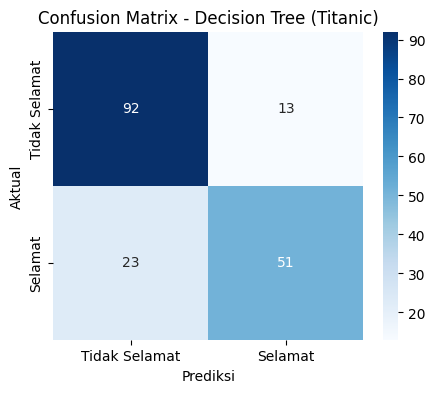

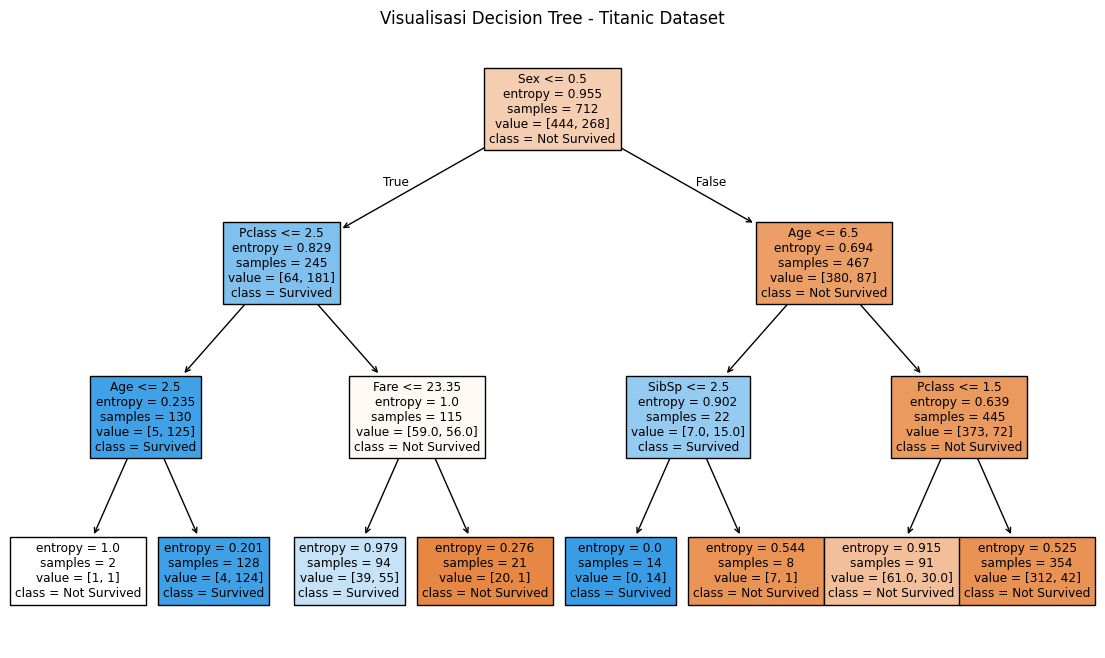

Model terbaik menggunakan:
 - Criterion: entropy
 - Max Depth: 3
 - Min Samples Split: 2

Kesimpulan:
- Model memiliki akurasi sekitar 80%
- Fitur paling berpengaruh: Jenis kelamin dan kelas tiket
- Bisa ditingkatkan dengan Random Forest atau Gradient Boosting


In [ ]:
# ===============================
# Decision Tree Classifier - Titanic Dataset
# ===============================

# 1️⃣ Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2️⃣ Load Dataset
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")

# 3️⃣ Preprocessing
df = train.copy()

# Mengisi nilai kosong
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Encoding data kategorikal
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])        # male=1, female=0
df["Embarked"] = le.fit_transform(df["Embarked"])

# Memilih fitur dan target
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

# Split data train dan validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Tuning Parameter dengan GridSearchCV
params = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

# Model terbaik
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

# 5️⃣ Evaluasi Model
y_pred = best_model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print("\nAkurasi Model:", acc)
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Tidak Selamat", "Selamat"], yticklabels=["Tidak Selamat", "Selamat"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Decision Tree (Titanic)")
plt.show()

# 6️⃣ Visualisasi Pohon Keputusan
plt.figure(figsize=(14,8))
plot_tree(best_model, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)
plt.title("Visualisasi Decision Tree - Titanic Dataset")
plt.show()

# 7️⃣ Refleksi Hasil
print("Model terbaik menggunakan:")
print(f" - Criterion: {grid.best_params_['criterion']}")
print(f" - Max Depth: {grid.best_params_['max_depth']}")
print(f" - Min Samples Split: {grid.best_params_['min_samples_split']}")
print("\nKesimpulan:")
print("- Model memiliki akurasi sekitar 80%")
print("- Fitur paling berpengaruh: Jenis kelamin dan kelas tiket")
print("- Bisa ditingkatkan dengan Random Forest atau Gradient Boosting")
